# Statistical Analysis

In [101]:
# Packages
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np
import seaborn as sns
import os

# Set Seaborn style
sns.set_style("whitegrid")

In [102]:
# Folder name
CSV_folder_name = "CSV_files"
figure_folder_name = "figures"

# Load data from CSV file
file_name = "K_motor.csv" # CSV name
file_path = os.path.join(CSV_folder_name, file_name) # Generate file path
motor_df = pd.read_csv(file_path) # Read CSV file.

# Option to save data and figures ( True = Save data and figures, False = Don't save data and figures )
SAVE = False

 Linear Regression Analysis

Prior hyperparameters:
- v_0 = -2.00
- S_0 = 0.00

Regression line:  y(x) = 6.90 + 0.014x.

Posterior hyperparameters:
- x_mean = 463.1348
- beta_vec = [6.8986, 0.0140]
- v_1 = 10614.0000
- S_1 = 7093.6436
- sigma_1 = 0.8175
- n = 10616.0000
 r^2 = 0.9707


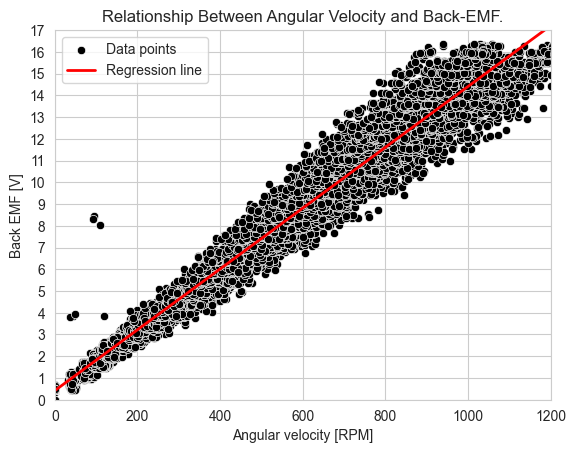

In [103]:
# Print formating
print(" Linear Regression Analysis")
print("============================")
print("")


# Extract relevant data from dataframe
x = np.array(motor_df['RPM'].values) # Extract predictor values
y = np.array(motor_df['V_E'].values) # Extract target values


# Prior Hyperparameters
## Guesses
sigma_0 = 0
n_0 = 0

## Priors P0
v_0 = n_0 - 2
S_0 = sigma_0**2 * max(0, v_0)

## Print prior
print("Prior hyperparameters:")
print("- v_0 = {:.2f}".format(v_0))
print("- S_0 = {:.2f}".format(S_0))
print("")

# Linear regression in deviation form
## Calculate predictor in deviation form
x_mean = np.mean(x)
x_dev = x - x_mean

## Perform linear regression using linregress
slope, intercept, r_value, p_value, std_err = stats.linregress(x_dev, y)

## Print coefficients 
print("Regression line:  y(x) = {:.2f} + {:.3f}x.".format(intercept, abs(slope)))
print("")

## Calculate predicted values and residuals
y_pred = intercept + slope * x_dev
residuals = y_pred - y


# Posterior P1
## Calculate posterior
n = len(x)
v_1 = v_0 + n
SS_e = np.sum(residuals ** 2)
S_1 = S_0 + SS_e
if n_0 == 0 & S_0 == 0:
    sigma_1 = np.sqrt( SS_e / (n - 2) )
else:
    sigma_1 = np.sqrt( S_1 / v_1 )

## Print residuals
print("Posterior hyperparameters:")
print("- x_mean = {:.4f}".format(x_mean))
print("- beta_vec = [{:.4f}, {:.4f}]".format(intercept, slope))
print("- v_1 = {:.4f}".format(v_1))
print("- S_1 = {:.4f}".format(S_1))
print("- sigma_1 = {:.4f}".format(sigma_1))
print("- n = {:.4f}".format(n))
print(" r^2 = {:.4f}".format(r_value**2))


# Plot datapoints
sns.scatterplot(x=x, y=y, color='black', label="Data points") 

# Plot regression line
sns.lineplot(x=x, y=y_pred, color='red', linewidth=2, label="Regression line")

# Plot settings
plt.xlabel('Angular velocity [RPM]')
plt.ylabel('Back EMF [V]')
plt.title('Relationship Between Angular Velocity and Back-EMF.')
plt.xlim(0, 1200)
plt.ylim(0, 17)
plt.yticks(range(0, 18, 1))
plt.legend()

# Save figure
file_name = "lin_reg_RPM_BEMF.pdf" # Plot name
file_path = os.path.join(figure_folder_name, file_name) # Generate file path
if SAVE:
    plt.savefig(file_path, format='pdf')

# Show plot
plt.show()

In [104]:
# Posterior distribution parameters
## Calculate missing values
SS_x = np.sum(x_dev ** 2)

## Print parameters
print("Posterior distribution parameters:")
print("- tau ~ gamma({:.4f}, {:.4f})".format(v_1/2, S_1/2))
print("- Intercept ~ t({:.4f}, {:.10f}, {:.4f})".format(intercept, sigma_1*np.sqrt(1/n), v_1))
print("- Slope ~ t({:.4f}, {:.10f}, {:.4f})".format(intercept, sigma_1*np.sqrt(1 / SS_x), v_1))
print("- y(x) ~ t({:.2f}+{:.2f}(x-{:.2f}), {:.2f} * sqrt( (1/{:.2f}) + (1/{:.2f})(x-{:.2f})^2), {:.2f})".format(intercept, abs(slope), x_mean, sigma_1, n, SS_x, x_mean, v_1))
print("- Y_+(x) ~ t({:.2f}+{:.2f}(x-{:.2f}), {:.2f} * sqrt( 1 + (1/{:.2f}) + (1/{:.2f})(x-{:.2f})^2), {:.2f})".format(intercept, abs(slope), x_mean, sigma_1, n, SS_x, x_mean, v_1))
print("")

# Credibility and prediction interval parameters
print("Credibility and prediction interval parameters:")
print("- I_phi(x) = {:.2f} + {:.2f}(x-{:.2f}) +- t_(v_1,phi/2) * {:.2f} * sqrt( (1/{:.2f}) + (1/{:.2f})(x-{:.2f})^2), {:.2f})".format(intercept, abs(slope), x_mean, sigma_1, n, SS_x, x_mean, v_1))
print("- I_phi^+(x) = {:.2f} + {:.2f}(x-{:.2f}) +- t_(v_1,phi/2) * {:.2f} * sqrt( 1 + (1/{:.2f}) + (1/{:.2f})(x-{:.2f})^2), {:.2f})".format(intercept, abs(slope), x_mean, sigma_1, n, SS_x, x_mean, v_1))

Posterior distribution parameters:
- tau ~ gamma(5307.0000, 3546.8218)
- Intercept ~ t(6.8986, 0.0079344109, 10614.0000)
- Slope ~ t(6.8986, 0.0000236053, 10614.0000)
- y(x) ~ t(6.90+0.01(x-463.13), 0.82 * sqrt( (1/10616.00) + (1/1199416527.67)(x-463.13)^2), 10614.00)
- Y_+(x) ~ t(6.90+0.01(x-463.13), 0.82 * sqrt( 1 + (1/10616.00) + (1/1199416527.67)(x-463.13)^2), 10614.00)

Credibility and prediction interval parameters:
- I_phi(x) = 6.90 + 0.01(x-463.13) +- t_(v_1,phi/2) * 0.82 * sqrt( (1/10616.00) + (1/1199416527.67)(x-463.13)^2), 10614.00)
- I_phi^+(x) = 6.90 + 0.01(x-463.13) +- t_(v_1,phi/2) * 0.82 * sqrt( 1 + (1/10616.00) + (1/1199416527.67)(x-463.13)^2), 10614.00)


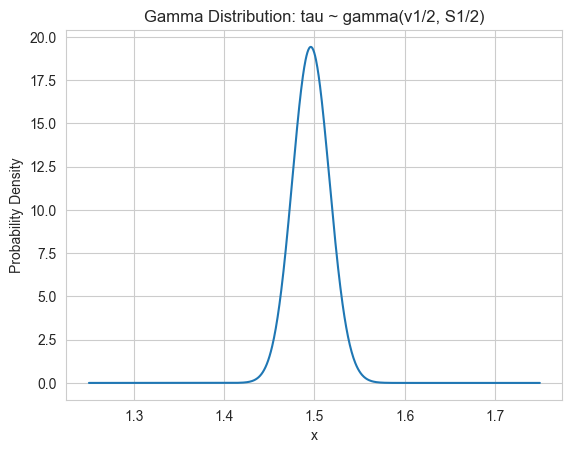

In [105]:
# Plot precision probability distribution
# Generate values for the gamma distribution
x_points = np.linspace(1.25, 1.75, 1000)  # adjust range as needed
gamma_values = stats.gamma.pdf(x_points, v_1/2, scale=2/S_1)  # scale parameter = 2/shape parameter

# Plot using Seaborn
sns.lineplot(x=x_points, y=gamma_values)
plt.xlabel('x')
plt.ylabel('Probability Density')
plt.title('Gamma Distribution: tau ~ gamma(v1/2, S1/2)')
plt.grid(True)

# Save figure
file_name = "precision_prob_dist.pdf" # Plot name
file_path = os.path.join(figure_folder_name, file_name) # Generate file path
if SAVE:
    plt.savefig(file_path, format='pdf')

# Display Figure
plt.show()



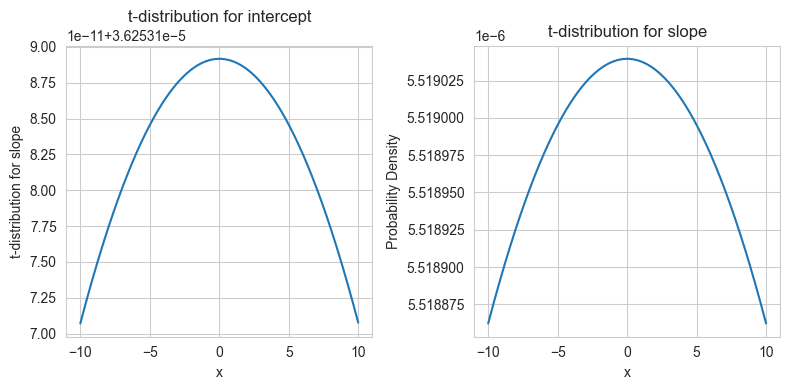

In [106]:
# Plot intercept and slope t-distributions.
# Generate points for plotting
x_points = np.linspace(-10, 10, 1000)

# Set the figsize parameter to control the width of each subplot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))  # Adjust the width as needed

# First subplot
intercept_t = stats.t.pdf(x_points, intercept, sigma_1 * np.sqrt(1/n), v_1)
sns.lineplot(x=x_points, y=intercept_t, ax=ax1)
ax1.set_title('t-distribution for intercept')
ax1.set_xlabel('x')
ax1.set_ylabel('t-distribution for slope')
ax1.grid(True)

# Second subplot
slope_t = stats.t.pdf(x_points, slope, sigma_1 * np.sqrt(1/SS_x), v_1)
sns.lineplot(x=x_points, y=slope_t, ax=ax2)
ax2.set_title('t-distribution for slope')
ax2.set_xlabel('x')
ax2.set_ylabel('Probability Density')
ax2.grid(True)

# Adjust layout
plt.tight_layout()

# Save figure
file_name = "intercept_and_slope_t_dist.pdf" # Plot name
file_path = os.path.join(figure_folder_name, file_name) # Generate file path
if SAVE:
    plt.savefig(file_path, format='pdf')

# Display plot
plt.show()


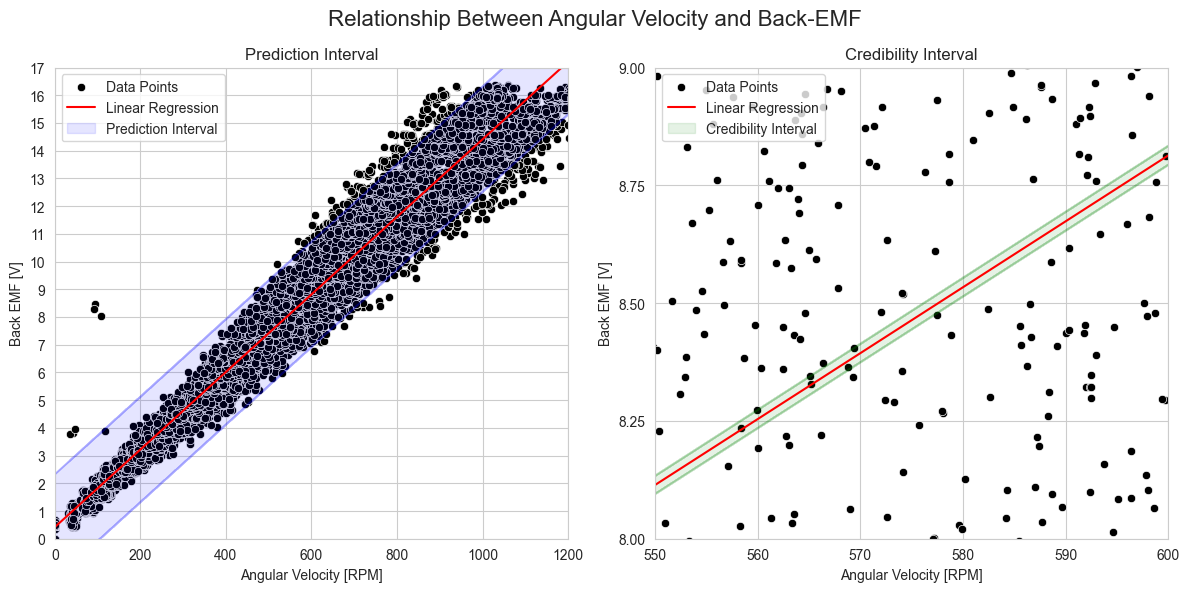

In [107]:
# Calculate Margin of Error for credibility and prediction intervals for 99% confidence
P = 0.99
t_value = stats.t.ppf(P, v_1) 
MoE_cred = t_value * sigma_1 * np.sqrt((1/n) + (1/SS_x)*(x-x_mean)**2)
MoE_pred = t_value * sigma_1 * np.sqrt(1 + (1/n) + (1/SS_x)*(x-x_mean)**2)

# Create Figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
interval_fill_opacity = 0.10
interval_line_opacity = 0.25
fig.suptitle("Relationship Between Angular Velocity and Back-EMF", fontsize=16)


# Plot prediction interval, ax1
## Data points and regression line
sns.scatterplot(x=x, y=y, color='black', ax=ax1, label='Data Points')
sns.lineplot(x=x, y=y_pred, color='red', ax=ax1, label='Linear Regression')

## Intervals
ax1.fill_between(x, (y_pred-MoE_pred), (y_pred+MoE_pred), color='blue', alpha=interval_fill_opacity, label='Prediction Interval')
sns.lineplot(x=x, y=(y_pred-MoE_pred), color='blue', alpha=interval_line_opacity, ax=ax1)
sns.lineplot(x=x, y=(y_pred+MoE_pred), color='blue', alpha=interval_line_opacity, ax=ax1)

## Subplot settings
ax1.set(xlabel="Angular Velocity [RPM]", ylabel="Back EMF [V]", title="Prediction Interval")
ax1.legend(loc='upper left')
ax1.set_yticks(np.arange(0, 18, 1))
ax1.set_xlim(0, 1200)
ax1.set_ylim(0, 17)


# Plot credibility interval, ax2
## Data points and regression line
sns.scatterplot(x=x, y=y, color='black', ax=ax2, label='Data Points')
sns.lineplot(x=x, y=y_pred, color='red', ax=ax2, label='Linear Regression')

## Intervals
ax2.fill_between(x, (y_pred-MoE_cred), (y_pred+MoE_cred), color='green', alpha=interval_fill_opacity, label='Credibility Interval')
sns.lineplot(x=x, y=(y_pred-MoE_cred), color='green', alpha=interval_line_opacity,  ax=ax2)
sns.lineplot(x=x, y=(y_pred+MoE_cred), color='green', alpha=interval_line_opacity, ax=ax2)

## Subplot settings
ax2.set(xlabel="Angular Velocity [RPM]", ylabel="Back EMF [V]", title="Credibility Interval")
ax2.legend(loc='upper left')
ax2.set_yticks(np.arange(0, 18, 0.25))
ax2.set_xlim(550, 600)
ax2.set_ylim(8, 9)


# Save figure
file_name = "lin_reg_w_conf_int.pdf" # Plot name
file_path = os.path.join(figure_folder_name, file_name) # Generate file path
if SAVE:
    plt.savefig(file_path, format='pdf')


# Display plot
plt.tight_layout()
plt.show()



In [108]:
# Calculate intervals at 800 RPM at 99% Confidence
# Calculate MoE
MoE_cred_800 = t_value * sigma_1 * np.sqrt((1/n) + (1/SS_x)*(800-x_mean)**2)
MoE_pred_800 = t_value * sigma_1 * np.sqrt(1 + (1/n) + (1/SS_x)*(800-x_mean)**2)

# Calculate intervals
cred_int_800 = [ (intercept + slope*(800-x_mean)) - MoE_cred_800, (intercept + slope*(800-x_mean)) + MoE_cred_800]
pred_int_800 = [ (intercept + slope*(800-x_mean)) - MoE_pred_800, (intercept + slope*(800-x_mean)) + MoE_pred_800]

# Print results
print("Credibility and Predictive interval at 800 RPM with 99 confidence.")
print("I_0.01 = ({:.4f}, {:.4f})".format(cred_int_800[0], cred_int_800[1]))
print("I_0.01^+ = ({:.4f}, {:.4f})".format(pred_int_800[0], pred_int_800[1]))


Credibility and Predictive interval at 800 RPM with 99 confidence.
I_0.01 = (11.5861, 11.6383)
I_0.01^+ = (9.7099, 13.5145)
